# Анализ результатов бенчмаркинга теплопроводности 2D
## Очистка от выбросов и визуализация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [2]:
def load_csv(filepath):
    try:
        df = pd.read_csv(filepath)
        print(f"Loaded {filepath}: {len(df)} records")
        return df
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None

files = {
    'cpu_onecore': 'benchmark/cpu_onecore.csv',
    'cpu_multicore': 'benchmark/cpu_multicore.csv', 
    'gpu': 'benchmark/gpu.csv'
}

data = {name: load_csv(path) for name, path in files.items()}

Loaded benchmark/cpu_onecore.csv: 40 records
Loaded benchmark/cpu_multicore.csv: 40 records
Loaded benchmark/gpu.csv: 40 records


In [3]:
def remove_outliers_iqr(df, column='time_sec', multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    mask = (df[column] >= lower_bound) & (df[column] <= upper_bound)
    return df[mask].copy(), {'removed': (~mask).sum(), 'kept': mask.sum()}

def aggregate_results(df, size_col='size', time_col='time_sec', multiplier=1.5):
    results = []
    for size, group in df.groupby(size_col):
        clean_group, stats = remove_outliers_iqr(group, time_col, multiplier)
        if len(clean_group) == 0:
            continue
        row = {
            'size': size,
            'n_runs_original': len(group),
            'n_runs_clean': len(clean_group),
            'outliers_removed': stats['removed'],
            'time_mean': clean_group[time_col].mean(),
            'time_std': clean_group[time_col].std(),
            'time_median': clean_group[time_col].median(),
            'time_min': clean_group[time_col].min(),
            'time_max': clean_group[time_col].max(),
            'error': clean_group['error'].iloc[0],
            'iterations': clean_group['iterations'].iloc[0],
        }
        results.append(row)
    return pd.DataFrame(results)

In [4]:
aggregated = {}
for name, df in data.items():
    if df is not None:
        aggregated[name] = aggregate_results(df, multiplier=1.5)
        print(f"\n{name.upper()}:")
        print(aggregated[name][['size', 'n_runs_original', 'outliers_removed', 'time_mean', 'time_std']].to_string(index=False))


CPU_ONECORE:
 size  n_runs_original  outliers_removed   time_mean   time_std
  128               10                 2    0.486395   0.008697
  256               10                 0    7.568525   0.103345
  512               10                 0  140.905371   8.011565
 1024               10                 0 1860.229107 236.043653

CPU_MULTICORE:
 size  n_runs_original  outliers_removed  time_mean  time_std
  128               10                 0   1.140830  0.545103
  256               10                 0   3.420936  0.590294
  512               10                 1  13.027789  1.061381
 1024               10                 2  72.402558  3.161639

GPU:
 size  n_runs_original  outliers_removed  time_mean  time_std
  128               10                 1   0.313930  0.001332
  256               10                 1   1.131401  0.003515
  512               10                 1   4.267332  0.006611
 1024               10                 0  33.225162  0.017736


## Tables for Report

In [5]:
def format_report_table(df_agg, device_name):
    table = df_agg[['size', 'time_mean', 'error', 'iterations']].copy()
    table.columns = ['Grid Size', 'Time (s)', 'Accuracy', 'Iterations']
    table['Grid Size'] = table['Grid Size'].apply(lambda x: f"{x}*{x}")
    table['Time (s)'] = table['Time (s)'].apply(lambda x: f"{x:.4f}")
    table['Accuracy'] = table['Accuracy'].apply(lambda x: f"{x:.2e}")
    print(f"\n### {device_name}")
    print(table.to_string(index=False))
    return table

for name in ['cpu_onecore', 'cpu_multicore', 'gpu']:
    if name in aggregated:
        format_report_table(aggregated[name], name.upper())


### CPU_ONECORE
Grid Size  Time (s) Accuracy  Iterations
  128*128    0.4864 7.53e-07       31000
  256*256    7.5685 9.91e-07      103000
  512*512  140.9054 9.92e-07      340000
1024*1024 1860.2291 1.37e-06     1000000

### CPU_MULTICORE
Grid Size Time (s) Accuracy  Iterations
  128*128   1.1408 7.53e-07       31000
  256*256   3.4209 9.91e-07      103000
  512*512  13.0278 9.92e-07      340000
1024*1024  72.4026 1.37e-06     1000000

### GPU
Grid Size Time (s) Accuracy  Iterations
  128*128   0.3139 7.53e-07       31000
  256*256   1.1314 9.91e-07      103000
  512*512   4.2673 9.92e-07      340000
1024*1024  33.2252 1.36e+01     1000000


In [6]:
def prepare_comparison_df(aggregated_dict, sizes=None):
    if sizes is None:
        sizes = [128, 256, 512, 1024]
    rows = []
    for size in sizes:
        row = {'size': f"{size}*{size}"}
        for name in ['cpu_onecore', 'cpu_multicore', 'gpu']:
            if name in aggregated_dict:
                match = aggregated_dict[name][aggregated_dict[name]['size'] == size]
                if len(match) > 0:
                    row[name] = match['time_mean'].values[0]
                else:
                    row[name] = np.nan
            else:
                row[name] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

comparison_df = prepare_comparison_df(aggregated)
print(comparison_df)

        size  cpu_onecore  cpu_multicore        gpu
0    128*128     0.486395       1.140830   0.313930
1    256*256     7.568525       3.420936   1.131401
2    512*512   140.905371      13.027789   4.267332
3  1024*1024  1860.229107      72.402558  33.225162


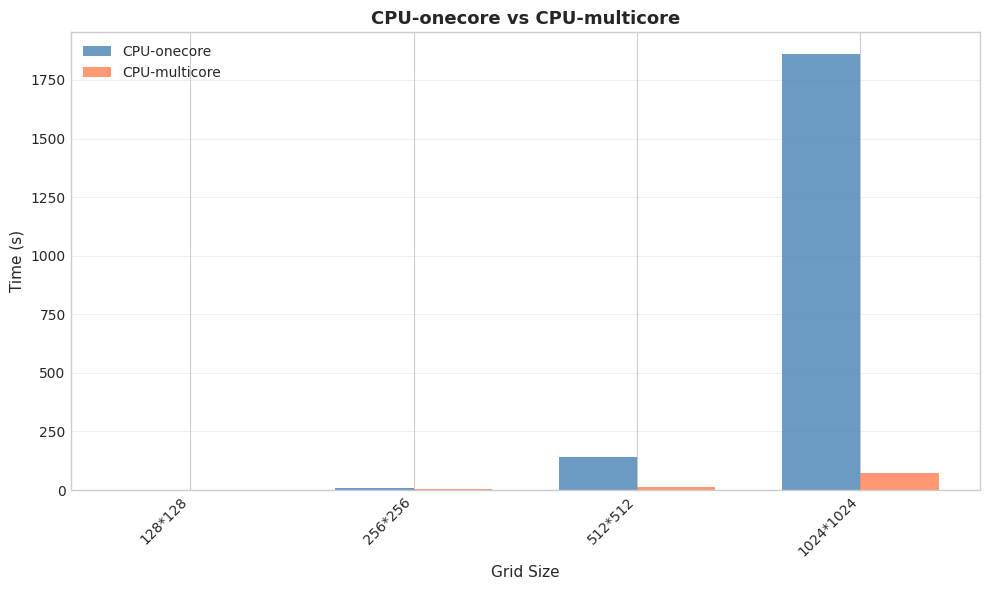

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

if 'cpu_onecore' in comparison_df.columns and 'cpu_multicore' in comparison_df.columns:
    bars1 = ax.bar(x - width/2, comparison_df['cpu_onecore'], width, 
                   label='CPU-onecore', alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, comparison_df['cpu_multicore'], width, 
                   label='CPU-multicore', alpha=0.8, color='coral')
    
    ax.set_xlabel('Grid Size', fontsize=11)
    ax.set_ylabel('Time (s)', fontsize=11)
    ax.set_title('CPU-onecore vs CPU-multicore', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['size'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cpu_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## Таблица и график этапов оптимизации GPU (сетка 512×512)

📊 Таблица этапов оптимизации GPU:
 Этап № Время выполнения Точность  Максимальное количество итераций                                                                        Комментарии
      1          13.8635 1.00e-06                           1000000                    Базовая версия OpenACC. Проверка сходимости на каждой итерации.
      2           6.8303 1.00e-06                           1000000                   Добавлен check_every=100. Разделение ядер с/без редукции ошибки.
      3           4.2626 9.92e-07                           1000000 check_every=1000. Замена копирования на std::swap. Явная инициализация acc_init().


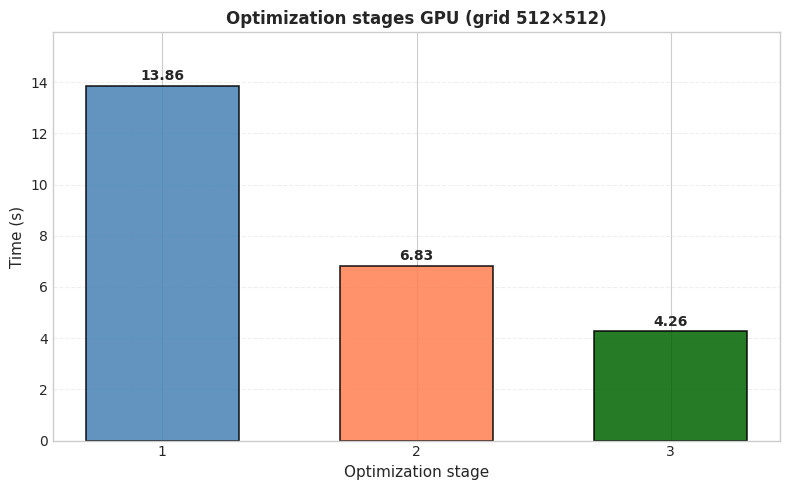


📋 Числовые значения для отчёта:
Этап 1: 13.8635 с
Этап 2: 6.8303 с
Этап 3: 4.2626 с


In [8]:
# 1. Загрузка и очистка данных по этапам
step_files = {
    'optim_steps/step1.csv': 'Базовая версия OpenACC. Проверка сходимости на каждой итерации.',
    'optim_steps/step2.csv': 'Добавлен check_every=100. Разделение ядер с/без редукции ошибки.',
    'optim_steps/step3.csv': 'check_every=1000. Замена копирования на std::swap. Явная инициализация acc_init().'
}

step_results = []
for fname, comment in step_files.items():
    df = pd.read_csv(fname)
    
    # Очистка выбросов по IQR (как в основных расчётах)
    Q1, Q3 = df['time_sec'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    mask = (df['time_sec'] >= Q1 - 1.5*IQR) & (df['time_sec'] <= Q3 + 1.5*IQR)
    clean = df[mask]
    
    if len(clean) == 0:
        print(f"⚠️ В {fname} не осталось данных после фильтрации выбросов")
        continue
        
    step_results.append({
        'Этап №': len(step_results) + 1,
        'Время выполнения': f"{clean['time_sec'].mean():.4f}",
        'Точность': f"{clean['error'].mean():.2e}",
        'Максимальное количество итераций': int(clean['max_iters'].iloc[0]),
        'Комментарии': comment
    })

# 2. Формирование и вывод таблицы (строго по шаблону)
opt_df = pd.DataFrame(step_results)
print("📊 Таблица этапов оптимизации GPU:")
print(opt_df.to_string(index=False))

# 3. Построение СТОЛБЧАТОЙ диаграммы динамики оптимизации
plt.figure(figsize=(8, 5))
x = opt_df['Этап №'].values
y = opt_df['Время выполнения'].astype(float).values

# Столбчатая диаграмма (вместо линейной!)
bars = plt.bar(x, y, width=0.6, color=['steelblue', 'coral', 'darkgreen'], 
               edgecolor='black', linewidth=1.2, alpha=0.85)

plt.xlabel('Optimization stage', fontsize=11)
plt.ylabel('Time (s)', fontsize=11)
plt.title('Optimization stages GPU (grid 512×512)', fontsize=12, fontweight='bold')
plt.xticks(x)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, max(y) * 1.15)  # Запас сверху для подписей

# Подписи значений над столбцами
for bar, val in zip(bars, y):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('gpu_optimization_stages.png', dpi=300, bbox_inches='tight')
plt.show()

# Вывод числовых значений для отчёта
print("\n📋 Числовые значения для отчёта:")
for _, row in opt_df.iterrows():
    print(f"Этап {row['Этап №']}: {row['Время выполнения']} с")

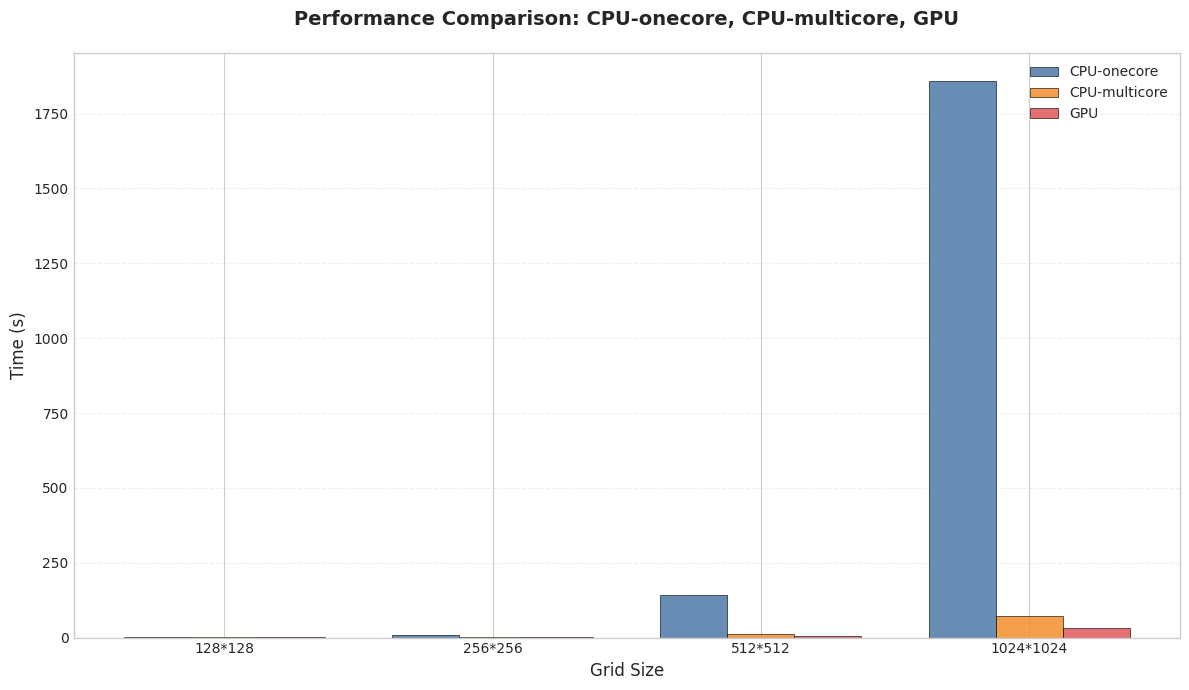


Final values for report:

128*128:
  CPU-onecore    : 0.4864 s
  CPU-multicore  : 1.1408 s
  GPU            : 0.3139 s

256*256:
  CPU-onecore    : 7.5685 s
  CPU-multicore  : 3.4209 s
  GPU            : 1.1314 s

512*512:
  CPU-onecore    : 140.9054 s
  CPU-multicore  : 13.0278 s
  GPU            : 4.2673 s

1024*1024:
  CPU-onecore    : 1860.2291 s
  CPU-multicore  : 72.4026 s
  GPU            : 33.2252 s


In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(comparison_df))
width = 0.25

colors = {'cpu_onecore': '#4E79A7', 'cpu_multicore': '#F28E2B', 'gpu': '#E15759'}
labels = {'cpu_onecore': 'CPU-onecore', 'cpu_multicore': 'CPU-multicore', 'gpu': 'GPU'}

offsets = [-width, 0, width]
for i, (name, color, label) in enumerate(zip(
    ['cpu_onecore', 'cpu_multicore', 'gpu'],
    [colors['cpu_onecore'], colors['cpu_multicore'], colors['gpu']],
    [labels['cpu_onecore'], labels['cpu_multicore'], labels['gpu']]
)):
    if name in comparison_df.columns:
        values = comparison_df[name].fillna(0)
        bars = ax.bar(x + offsets[i], values, width, label=label, 
                     color=color, alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Grid Size', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Performance Comparison: CPU-onecore, CPU-multicore, GPU', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['size'], rotation=0, ha='center', fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFinal values for report:")
for _, row in comparison_df.iterrows():
    print(f"\n{row['size']}:")
    for name in ['cpu_onecore', 'cpu_multicore', 'gpu']:
        if name in row and not np.isnan(row[name]):
            print(f"  {labels[name]:15}: {row[name]:.4f} s")